In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls /content/drive/MyDrive


'1702128932204_SP23-F117 Yunes Abdulghani Mohammed Ghaleb.pdf'
 20250110_113836.jpg
'20250121_082345 (1).jpg'
'20250121_082345 (2).jpg'
'20250121_082345 (3).jpg'
 20250121_082345.jpg
 20250121_083109.jpg
 20250121_083302.jpg
 20250511_154956.mp4
 annotated_parking_image.jpeg
 Applefruit_dataset.zip
 applefruit_model.h5
 archive.zip
 best_wbc_model_FINAL.pth
 best_wbc_model.pth
 best_wbc_ultimate.pth
 Blood_Test_Model_Template.xlsx
'Certificate - Yunes Abdulghani Mohammed Ghaleb.pdf'
 Classroom
'Colab Notebooks'
 digital-8161427_960_720.png
'EVS-Yunes Abulghani Mohammed Ghaleb.gdoc'
 GNSS_raw_train.csv
'Jan 18, 2025 at 12:14 PM.jpg'
 Lime_frout.zip
 lime_model.h5
'My projects'
 parking_dataset
'Parking Dataset'
'Parking Dataset1'
 parking_frames
 parking_labeled
 parking_model.h5
 parking_model_vgg16.h5
'Parking Videos'
'PCM-Yunes Abulghani Mohammed Ghaleb.gdoc'
 sample_two_patients.xlsx
 Train
 Train.rar
 ultimate_wbc_system_v2.py
'Untitled document.gdoc'
'Untitled folder'
 VID-2024093

In [3]:
!ls /content/drive/MyDrive/Train.rar


/content/drive/MyDrive/Train.rar


In [4]:
!apt-get install unrar -y


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


In [5]:
!unrar x "/content/drive/MyDrive/Train.rar" /content/


Streaming output truncated to the last 5000 lines.
Extracting  /content/Train/Neutrophil/95-8-1-1_256_1.jpg                  51%  OK 
Extracting  /content/Train/Neutrophil/95-8-1-1_257_1.jpg                  51%  OK 
Extracting  /content/Train/Neutrophil/95-8-1-1_259_1.jpg                  51%  OK 
Extracting  /content/Train/Neutrophil/95-8-1-1_25_1.jpg                   51%  OK 
Extracting  /content/Train/Neutrophil/95-8-1-1_265_1.jpg                  51%  OK 
Extracting  /content/Train/Neutrophil/95-8-1-1_268_1.jpg                  52%  OK 
Extracting  /content/Train/Neutrophil/95-8-1-1_269_1.jpg                  52%  OK 
Extracting  /content/Train/Neutrophil/95-8-1-1_270_1.jpg                  52%  OK 
Extracting  /content/Train/Neutrophil/95-8-1-1_274_3.jpg                  52%  OK 
Extracting  /content/Train/Neutrophil/95-8-1-1_275_2.jpg                  52%  OK 
Extracting  /content/Train/Ne

In [6]:
!ls /content


drive  sample_data  Train


In [7]:
!ls /content/Train


Basophil  Eosinophil  Lymphocyte  Monocyte  Neutrophil


In [8]:
DATA_DIR = "/content/Train"


In [ ]:
# هذا الكود الصحيح والاصلي
# Ultimate WBC Training System (FINAL)
# ==========================================
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

# ==========================================
# 1. CONFIG
# ==========================================
DATA_DIR = "/content/Train"
MODEL_SAVE_PATH = "/content/drive/MyDrive/best_wbc_ultimate.pth"
NUM_CLASSES = 5
BATCH_SIZE = 32
EPOCHS = 30
IMG_SIZE = 224
LR = 3e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASS_NAMES = ["Basophil", "Eosinophil", "Lymphocyte", "Monocyte", "Neutrophil"]

print("Using device:", DEVICE)

# ==========================================
# 2. TRANSFORMS
# ==========================================
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# 3. LOAD & SPLIT DATA
# ==========================================
full_dataset = datasets.ImageFolder(DATA_DIR)
indices = torch.randperm(len(full_dataset))
train_size = int(0.85 * len(indices))

train_ds = Subset(datasets.ImageFolder(DATA_DIR, transform=train_tf),
                  indices[:train_size])
val_ds = Subset(datasets.ImageFolder(DATA_DIR, transform=val_tf),
                indices[train_size:])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Total images:", len(full_dataset))

# ==========================================
# 4. MODEL
# ==========================================
model = models.efficientnet_v2_s(
    weights=models.EfficientNet_V2_S_Weights.DEFAULT
)
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    NUM_CLASSES
)
model.to(DEVICE)

# ==========================================
# 5. TRAINING SETUP
# ==========================================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.cuda.amp.GradScaler()

best_acc = 0

# ==========================================
# 6. TRAIN LOOP
# ==========================================
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()

    scheduler.step()

    # VALIDATION
    model.eval()
    preds, labs = [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out = model(imgs)
            preds.extend(out.argmax(1).cpu().numpy())
            labs.extend(labels.cpu().numpy())

    acc = np.mean(np.array(preds) == np.array(labs))
    print(f"Loss: {running_loss/len(train_loader):.4f} | Val Acc: {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)

# ==========================================
# 7. FINAL REPORT
# ==========================================
print("\nFINAL MEDICAL REPORT")
print(classification_report(labs, preds, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(labs, preds)
print("Confusion Matrix:\n", cm)

print("✅ Training completed successfully")


Using device: cuda
Total images: 10175
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 188MB/s]
/tmp/ipython-input-2862335583.py:87: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Epoch 1/30:   0%|          | 0/271 [00:00<?, ?it/s]/tmp/ipython-input-2862335583.py:102: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/30: 100%|██████████| 271/271 [02:03<00:00,  2.19it/s]


Loss: 0.5101 | Val Acc: 0.9614


KeyboardInterrupt: 

Using device: cuda
Total images: 10175
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 201MB/s]
/tmp/ipython-input-500789597.py:93: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Epoch 1/30:   0%|          | 0/271 [00:00<?, ?it/s]/tmp/ipython-input-500789597.py:117: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/30: 100%|██████████| 271/271 [02:04<00:00,  2.17it/s]


Loss: 0.5132 | Val Acc: 0.9862


Epoch 2/30: 100%|██████████| 271/271 [01:52<00:00,  2.41it/s]


Loss: 0.4358 | Val Acc: 0.9895


...

Loss: 0.3903 | Val Acc: 0.9921


Epoch 29/30: 100%|██████████| 271/271 [01:50<00:00,  2.45it/s]


Loss: 0.3905 | Val Acc: 0.9921


Epoch 30/30: 100%|██████████| 271/271 [01:50<00:00,  2.44it/s]


Loss: 0.3905 | Val Acc: 0.9928


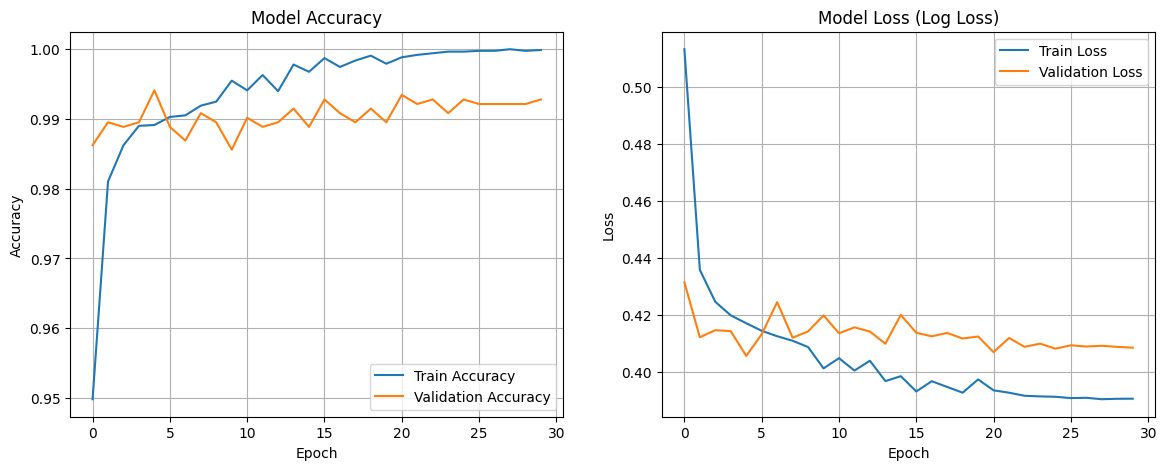

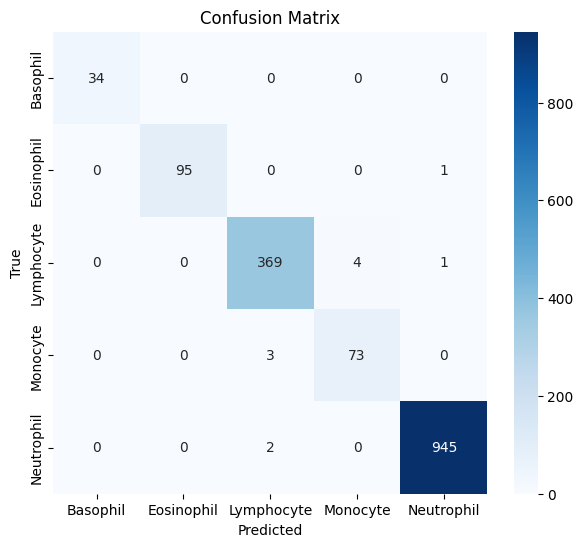


FINAL MEDICAL REPORT
              precision    recall  f1-score   support

    Basophil     1.0000    1.0000    1.0000        34
  Eosinophil     1.0000    0.9896    0.9948        96
  Lymphocyte     0.9866    0.9866    0.9866       374
    Monocyte     0.9481    0.9605    0.9542        76
  Neutrophil     0.9979    0.9979    0.9979       947

    accuracy                         0.9928      1527
   macro avg     0.9865    0.9869    0.9867      1527
weighted avg     0.9928    0.9928    0.9928      1527



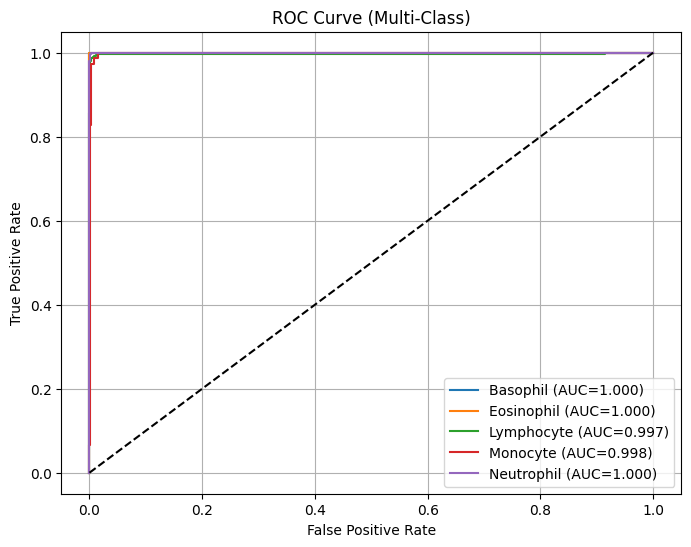

✅ Training & Evaluation completed successfully


In [9]:
# ==========================================
# Ultimate WBC Training System (FINAL + VISUAL EVALUATION)
# ==========================================

import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tqdm import tqdm

# ==========================================
# 1. CONFIG
# ==========================================
DATA_DIR = "/content/Train"
MODEL_SAVE_PATH = "/content/drive/MyDrive/best_wbc_ultimate.pth"

NUM_CLASSES = 5
BATCH_SIZE = 32
EPOCHS = 30
IMG_SIZE = 224
LR = 3e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASS_NAMES = ["Basophil", "Eosinophil", "Lymphocyte", "Monocyte", "Neutrophil"]

print("Using device:", DEVICE)

# ==========================================
# 2. TRANSFORMS
# ==========================================
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# 3. LOAD & SPLIT DATA
# ==========================================
full_dataset = datasets.ImageFolder(DATA_DIR)
indices = torch.randperm(len(full_dataset))
train_size = int(0.85 * len(indices))

train_ds = Subset(datasets.ImageFolder(DATA_DIR, transform=train_tf),
                  indices[:train_size])
val_ds = Subset(datasets.ImageFolder(DATA_DIR, transform=val_tf),
                indices[train_size:])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print("Total images:", len(full_dataset))

# ==========================================
# 4. MODEL (UNCHANGED)
# ==========================================
model = models.efficientnet_v2_s(
    weights=models.EfficientNet_V2_S_Weights.DEFAULT
)
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    NUM_CLASSES
)
model.to(DEVICE)

# ==========================================
# 5. TRAINING SETUP (UNCHANGED)
# ==========================================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.cuda.amp.GradScaler()

best_acc = 0.0

# ==========================================
# 6. STORAGE FOR GRAPHS
# ==========================================
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# ==========================================
# 7. TRAIN LOOP
# ==========================================
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0
    correct, total = 0, 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    scheduler.step()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    correct, total = 0, 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)

            val_loss += loss.item()
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    val_loss /= len(val_loader)
    val_acc = correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)

# ==========================================
# 8. LEARNING CURVES
# ==========================================
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Loss (Log Loss)")
plt.legend()
plt.grid(True)

plt.show()

# ==========================================
# 9. CONFUSION MATRIX (FORMAL)
# ==========================================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# ==========================================
# 10. CLASSIFICATION REPORT
# ==========================================
print("\nFINAL MEDICAL REPORT")
print(classification_report(all_labels, all_preds,
                            target_names=CLASS_NAMES, digits=4))

# ==========================================
# 11. ROC CURVE + AUC (MULTI-CLASS)
# ==========================================
y_true = label_binarize(all_labels, classes=range(NUM_CLASSES))
y_scores = np.array(all_probs)

plt.figure(figsize=(8,6))
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_scores[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{CLASS_NAMES[i]} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-Class)")
plt.legend()
plt.grid(True)
plt.show()

print("✅ Training & Evaluation completed successfully")


In [ ]:
%%writefile ultimate_wbc_system_v2.py
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
from torchvision.models.feature_extraction import create_feature_extractor
from tqdm import tqdm

# ==========================================
# 1. الإعدادات المركزية (Config)
# ==========================================
class Config:
    DATA_DIR = "/content/wbc_data/Train"  # المسار المحلي السريع بعد فك الضغط
    EXTERNAL_DIR = "/content/drive/MyDrive/external_test" # مجلد اختياري لصور خارجية تماماً
    MODEL_SAVE_PATH = "/content/drive/MyDrive/best_wbc_v2_ultimate.pth"
    NUM_CLASSES = 5
    BATCH_SIZE = 32
    EPOCHS = 30
    IMG_SIZE = 224
    LR = 3e-4
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    CLASS_NAMES = ["Basophil", "Eosinophil", "Lymphocyte", "Monocyte", "Neutrophil"]

# ==========================================
# 2. تحويلات البيانات (Augmentation)
# ==========================================
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(30),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

# ==========================================
# 3. بناء الموديل المتقدم (EfficientNet-V2-S)
# ==========================================
def build_ultimate_model():
    model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(num_ftrs, Config.NUM_CLASSES)
    )
    return model.to(Config.DEVICE)

# ==========================================
# 4. وظيفة Grad-CAM لتفسير النتائج
# ==========================================
def run_grad_cam(model, image_tensor, target_label, class_names):
    model.eval()
    # استخراج الخرائط من آخر طبقة في الميزات
    extractor = create_feature_extractor(model, return_nodes={"features": "feat_map"})
    image_tensor = image_tensor.unsqueeze(0).to(Config.DEVICE)
    image_tensor.requires_grad_()

    outputs = extractor(image_tensor)
    logits = model(image_tensor)

    score = logits[0, target_label]
    model.zero_grad()
    score.backward()

    grads = image_tensor.grad
    weights = grads.mean(dim=(2, 3), keepdim=True)
    cam = torch.relu((weights * outputs["feat_map"]).sum(dim=1))
    cam = cam / (cam.max() + 1e-7)
    return cam[0].cpu().detach().numpy()

# ==========================================
# 5. دورة التدريب والتقييم
# ==========================================
def train_system():
    # التحقق من وجود البيانات
    if not os.path.exists(Config.DATA_DIR):
        print(f"❌ خطأ: لم نجد المجلد {Config.DATA_DIR}. تأكد من فك الضغط أولاً.")
        return

    full_ds = datasets.ImageFolder(Config.DATA_DIR)
    train_size = int(0.85 * len(full_ds))
    val_size = len(full_ds) - train_size
    train_idx, val_idx = torch.utils.data.random_split(range(len(full_ds)), [train_size, val_size])

    # ربط التحويلات لكل قسم بشكل منفصل
    train_ds = torch.utils.data.Subset(datasets.ImageFolder(Config.DATA_DIR, transform=data_transforms['train']), train_idx)
    val_ds = torch.utils.data.Subset(datasets.ImageFolder(Config.DATA_DIR, transform=data_transforms['val']), val_idx)

    train_loader = DataLoader(train_ds, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    model = build_ultimate_model()
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=Config.LR, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=Config.EPOCHS)
    scaler = torch.amp.GradScaler(device_type="cuda")

    best_acc = 0
    print(f"🚀 البدء في تدريب النظام النهائي على {Config.DEVICE}...")

    for epoch in range(Config.EPOCHS):
        model.train()
        r_loss = 0
        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{Config.EPOCHS}"):
            imgs, labels = imgs.to(Config.DEVICE), labels.to(Config.DEVICE)
            optimizer.zero_grad()
            with torch.amp.autocast(device_type="cuda"):
                out = model(imgs)
                loss = criterion(out, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            r_loss += loss.item()

        scheduler.step()

        # التقييم الشامل
        model.eval()
        all_p, all_l = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(Config.DEVICE), labels.to(Config.DEVICE)
                out = model(imgs)
                all_p.extend(out.argmax(1).cpu().numpy())
                all_l.extend(labels.cpu().numpy())

        acc = (np.array(all_p) == np.array(all_l)).mean()
        print(f"✅ Loss: {r_loss/len(train_loader):.4f} | Accuracy: {acc:.4f}")

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), "best_model.pth")
            torch.save(model.state_dict(), Config.MODEL_SAVE_PATH)

    # التقرير الطبي النهائي
    print("\n" + "="*50 + "\nالتقرير الطبي النهائي\n" + "="*50)
    print(classification_report(all_l, all_p, target_names=Config.CLASS_NAMES, digits=4))

    # حساب النوعية (Specificity)
    cm = confusion_matrix(all_l, all_p)
    for i, cls in enumerate(Config.CLASS_NAMES):
        tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
        fp = cm[:,i].sum() - cm[i,i]
        spec = tn / (tn + fp)
        print(f"{cls:12s} | Specificity: {spec:.4f}")

    # عرض Grad-CAM لعينة عشوائية
    sample_img, sample_lbl = val_ds[0]
    cam_mask = run_grad_cam(model, sample_img, sample_lbl, Config.CLASS_NAMES)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(sample_img.permute(1,2,0).numpy() * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406])
    plt.title("Original Cell")
    plt.subplot(1, 2, 2)
    plt.imshow(cam_mask, cmap='jet')
    plt.title(f"Grad-CAM (Attention): {Config.CLASS_NAMES[sample_lbl]}")
    plt.savefig("diagnostic_insight.png")
    plt.show()

if __name__ == "__main__":
    train_system()